# Playing with the `make_moons` dataset in PyTorch


In [35]:
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torchinfo import summary
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from sklearn.datasets import make_moons
import utils


In [36]:
class Timer:
    def __init__(self):
        self.time = None

    def __enter__(self):
        self.time = time.time()

    def __exit__(self, exc_type, exc_value, exc_traceback):
        time_passed = time.time() - self.time
        print(f'** {time_passed:.2f} seconds.')


In [37]:
def plot_decision_boundary(X, y, model, steps=1000, cmap='Paired'):
    cmap = plt.get_cmap(cmap)

    # Define region of interest by data limits
    xmin, xmax = X[:, 0].min() - 1, X[:, 0].max() + 1
    ymin, ymax = X[:, 1].min() - 1, X[:, 1].max() + 1
    x_span = np.linspace(xmin, xmax, steps)
    y_span = np.linspace(ymin, ymax, steps)
    xx, yy = np.meshgrid(x_span, y_span)

    # Make predictions across region of interest
    model.eval()
    with torch.no_grad():
        inputs = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
        outputs = model(inputs)
        # Assuming binary classification with one output node or two output nodes
        if outputs.shape[1] > 1:
            _, labels = torch.max(outputs, 1)
        else:
            labels = (outputs > 0.5).int()
        labels = labels.cpu().numpy()

    # Plot decision boundary in region of interest
    z = labels.reshape(xx.shape)

    fig, ax = plt.subplots()
    ax.contourf(xx, yy, z, cmap=cmap, alpha=0.5)

    # Get predicted labels on training data and plot
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, lw=0)

    return fig, ax


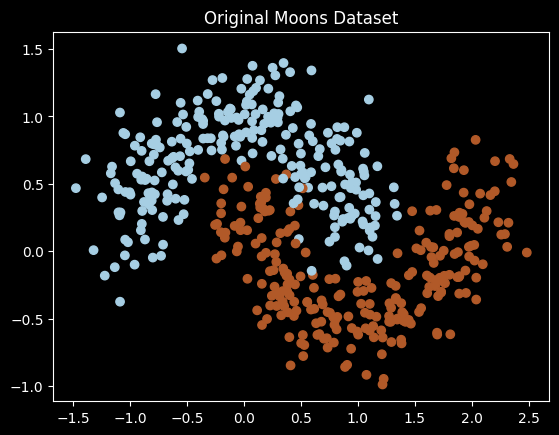

In [38]:
# 1. Generate the dataset
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, cmap='Paired')
plt.title("Original Moons Dataset")
plt.show()


In [39]:
# 2. Define a simple neural network model
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

model = SimpleNN()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [40]:
# 3. Training loop
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

print("Starting training...")
with Timer():
    history_loss = []  # Initialize the list before training
    epochs = 1001
    for epoch in range(1001):
        # Forward pass
        model.train()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)

        # Store the loss value (use .item() to get a standard Python float)
        history_loss.append(loss.item())

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 200 == 0:
            print(f"Epoch [{epoch}/1000], Loss: {loss.item():.4f}")


Starting training...
Epoch [0/1000], Loss: 0.6914
Epoch [200/1000], Loss: 0.0391
Epoch [400/1000], Loss: 0.0299
Epoch [600/1000], Loss: 0.0278
Epoch [800/1000], Loss: 0.0268
Epoch [1000/1000], Loss: 0.0261
** 1.97 seconds.


In [41]:
def evaluate(model, dataloader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    # tqdm creates the progress bar (22/22 [=======])
    progress_bar = tqdm(dataloader, desc="Evaluating", unit="step")

    with torch.no_grad():
        for inputs, targets in progress_bar:
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            # Calculate metrics
            total_loss += loss.item() * inputs.size(0)
            predictions = (outputs > 0.5).float()
            correct += (predictions == targets).sum().item()
            total += targets.size(0)

            # Update the progress bar with live loss and accuracy
            progress_bar.set_postfix(loss=f"{total_loss/total:.4f}",
                                     accuracy=f"{correct/total:.4f}")

    return [total_loss / total, correct / total]

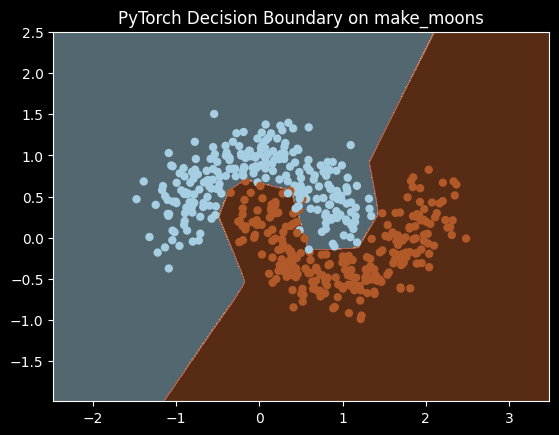

In [42]:
# 4. Plot results
plot_decision_boundary(X, y, model)
plt.title("PyTorch Decision Boundary on make_moons")
plt.show()


In [43]:
model.eval()


SimpleNN(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [44]:
# (batch_size, input_features)
summary(model, input_size=(1, 2))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleNN                                 [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 16]                   48
│    └─ReLU: 2-2                         [1, 16]                   --
│    └─Linear: 2-3                       [1, 16]                   272
│    └─ReLU: 2-4                         [1, 16]                   --
│    └─Linear: 2-5                       [1, 1]                    17
│    └─Sigmoid: 2-6                      [1, 1]                    --
Total params: 337
Trainable params: 337
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [45]:
# 1. Set the model to evaluation mode
model.eval()

SimpleNN(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [46]:
# Create dataset and loader (assuming batch_size=32)
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32)

In [47]:
results = evaluate(model, dataloader, criterion)
print(results)

Evaluating: 100%|██████████| 16/16 [00:00<00:00, 273.51step/s, accuracy=0.9900, loss=0.0260]

[0.026044803854078053, 0.99]


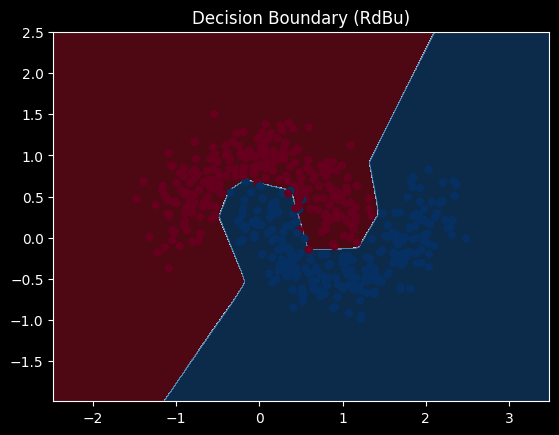

In [48]:
# ... after training your model ...
# equivalent to utils.plot_decision_boundary(X, y, model, cmap='RdBu')
utils.plot_decision_boundary(X, y, model, cmap='RdBu')
plt.title("Decision Boundary (RdBu)")
plt.show()

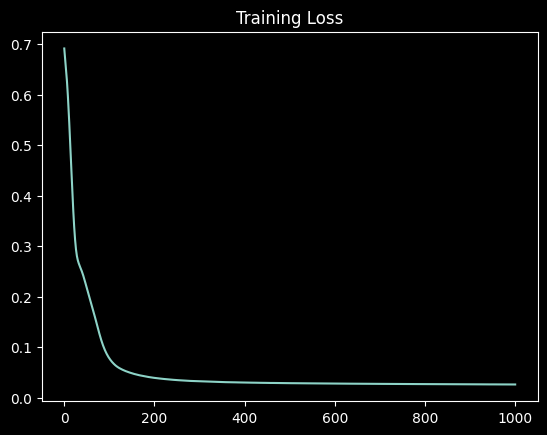

In [49]:
plt.plot(history_loss)
plt.title("Training Loss")
plt.show()

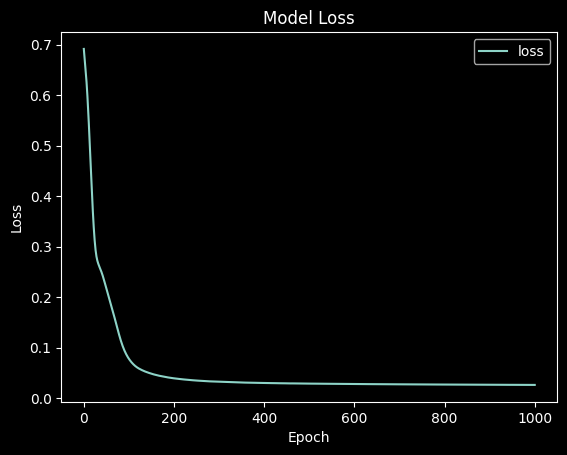

In [50]:
# Equivalent to plt.plot([i for i in range(epochs)], history.history['loss'])
plt.plot(range(len(history_loss)), history_loss, label='loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [51]:
# Since you used epochs = 1001 in your training loop, the plot will show 1001 points. If the loss drops very quickly at the beginning, you can "zoom in" on the later epochs by slicing the list:

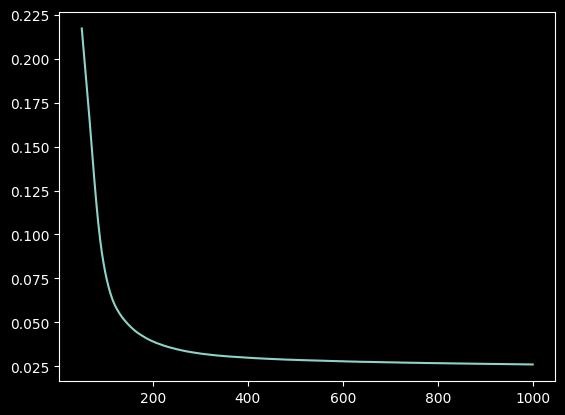

In [52]:
plt.plot(range(50, len(history_loss)), history_loss[50:])
